<a href="https://colab.research.google.com/github/DilshanWMP/DRL-laptop-thermal-management/blob/main/DRL_laptop_thermal_management.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git config --global user.email "praveenwmd@gmail.com"
!git config --global user.name "DilshanWMP"

!git clone https://github.com/DilshanWMP/DRL-laptop-thermal-management.git

import os
os.chdir('/content/DRL-laptop-thermal-management')

print("✅ Connected to GitHub repo!")

Cloning into 'DRL-laptop-thermal-management'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 6 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), done.
✅ Connected to GitHub repo!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Load the Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/DRL-laptop-thermal-management/Laptop_Motherboard_Health_Monitoring_Dataset.csv')

print("Dataset loaded successfully!")
print(f"\n=== DATASET SHAPE ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print(f"\n=== FIRST 5 ROWS ===")
print(df.head())

print(f"\n=== COLUMN NAMES ===")
print(df.columns.tolist())

print(f"\n=== DATA TYPES ===")
print(df.dtypes)

Dataset loaded successfully!

=== DATASET SHAPE ===
Rows: 2000, Columns: 8

=== FIRST 5 ROWS ===
            ModelName   CPUUsage   RAMUsage  Temperature    Voltage  \
0  Dell Inspiron 6880  48.447212  73.770260    59.971364  14.807143   
1   Dell ZenBook 2266  54.725241  25.221819    39.165106  15.727814   
2    Dell Galaxy 5903  26.693319  49.900628    93.052670  17.437338   
3   Dell ZenBook 8084  65.591652  29.603866    92.580189  10.645216   
4  Dell Inspiron 8884  24.395216  25.792754    76.175988  15.325681   

   DiskUsage  FanSpeed ProblemDetected  
0  15.502708      3507    Disk Failure  
1   4.421022      1037      No Problem  
2  25.180064      3244    Disk Failure  
3  57.713538      3731      No Problem  
4  83.788169      2830    Disk Failure  

=== COLUMN NAMES ===
['ModelName', 'CPUUsage', 'RAMUsage', 'Temperature', 'Voltage', 'DiskUsage', 'FanSpeed', 'ProblemDetected']

=== DATA TYPES ===
ModelName           object
CPUUsage           float64
RAMUsage           float64

Check Data Quality

In [5]:
print("=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== BASIC STATISTICS ===")
print(df.describe())

print("\n=== UNIQUE VALUES IN ProblemDetected ===")
print(df['ProblemDetected'].value_counts())

=== MISSING VALUES ===
ModelName          0
CPUUsage           0
RAMUsage           0
Temperature        0
Voltage            0
DiskUsage          0
FanSpeed           0
ProblemDetected    0
dtype: int64

=== BASIC STATISTICS ===
          CPUUsage     RAMUsage  Temperature      Voltage    DiskUsage  \
count  2000.000000  2000.000000  2000.000000  2000.000000  2000.000000   
mean     50.300210    50.938186    59.763022    15.072214    50.060845   
std      28.909198    28.481887    22.928808     2.878348    29.241174   
min       0.004006     0.002407    20.045716    10.004278     0.153563   
25%      25.399382    27.393268    39.574359    12.594651    23.319083   
50%      51.564640    50.559759    60.571872    15.157480    51.107317   
75%      75.240736    75.009930    78.646903    17.523345    75.659567   
max      99.992228    99.960012    99.976932    19.999478    99.876173   

          FanSpeed  
count  2000.000000  
mean   2987.593000  
std    1129.953471  
min    1000.000000 

Visualize Distributions

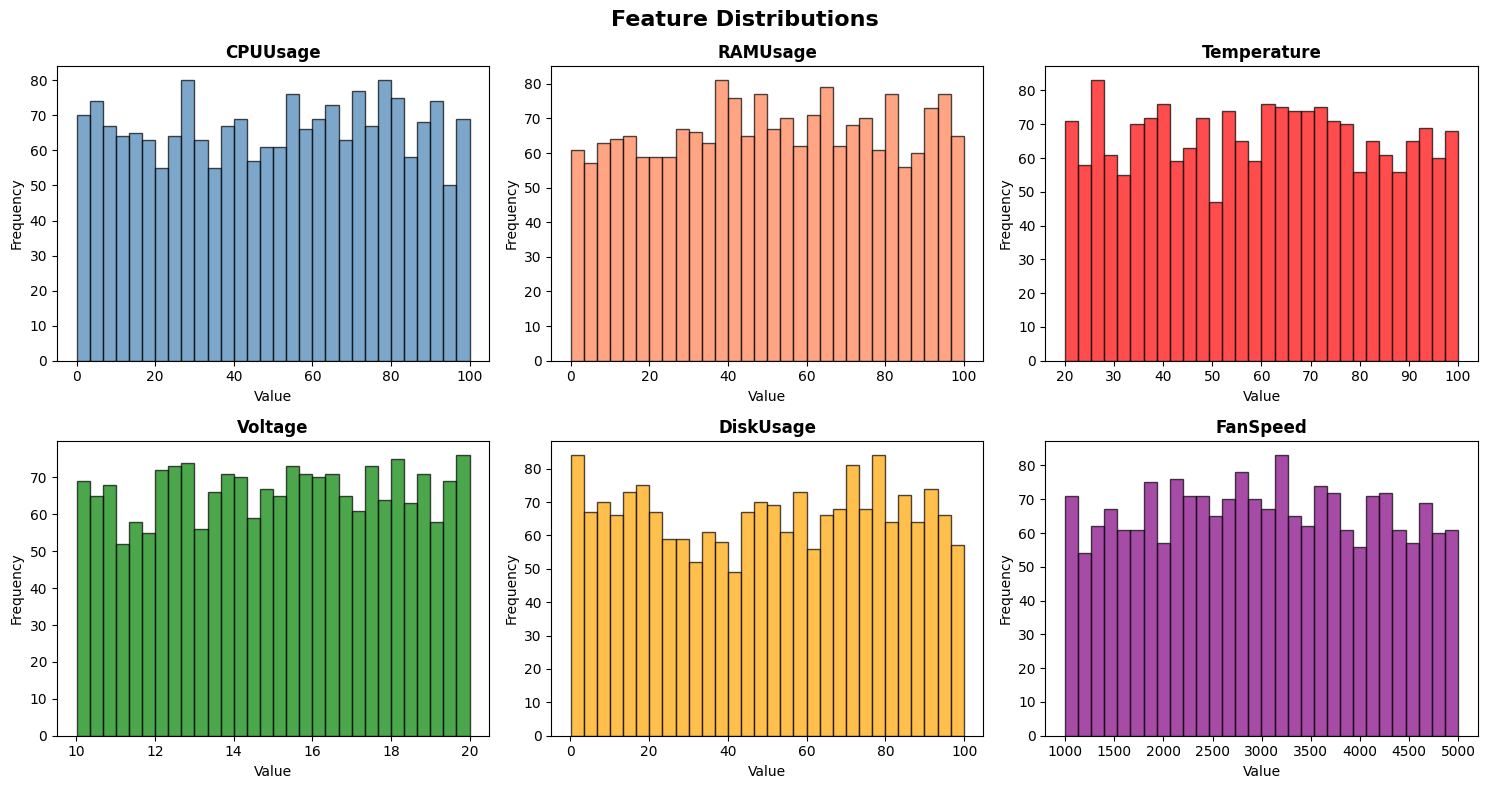

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Feature Distributions', fontsize=16, fontweight='bold')

features = ['CPUUsage', 'RAMUsage', 'Temperature', 'Voltage', 'DiskUsage', 'FanSpeed']
colors = ['steelblue', 'coral', 'red', 'green', 'orange', 'purple']

for i, (feature, color) in enumerate(zip(features, colors)):
    row, col = i // 3, i % 3
    axes[row, col].hist(df[feature], bins=30, color=color, edgecolor='black', alpha=0.7)
    axes[row, col].set_title(feature, fontsize=12, fontweight='bold')
    axes[row, col].set_xlabel('Value')
    axes[row, col].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

 Temperature vs Fan Speed

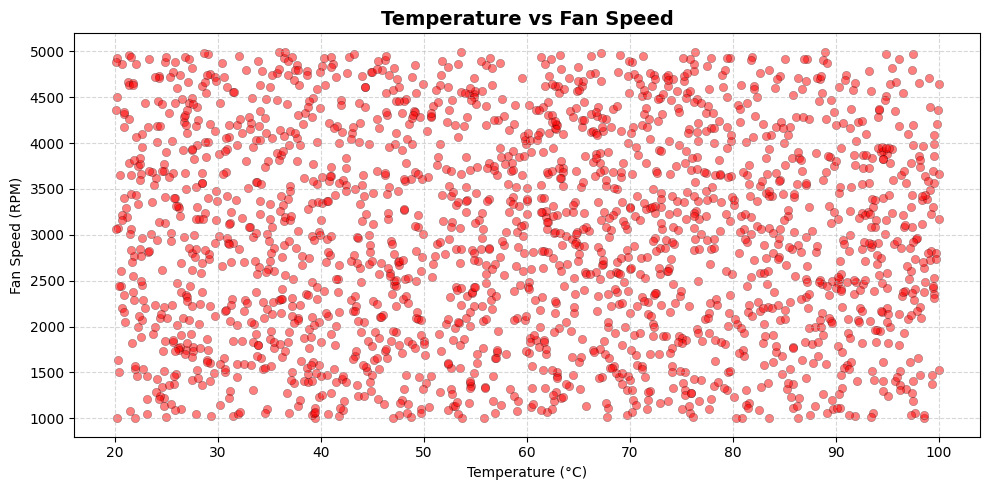

Correlation between Temperature and FanSpeed: -0.0119


In [7]:
plt.figure(figsize=(10, 5))
plt.scatter(df['Temperature'], df['FanSpeed'],
            alpha=0.5, color='red', edgecolors='black', linewidth=0.3)
plt.title('Temperature vs Fan Speed', fontsize=14, fontweight='bold')
plt.xlabel('Temperature (°C)')
plt.ylabel('Fan Speed (RPM)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Correlation between Temperature and FanSpeed:",
      round(df['Temperature'].corr(df['FanSpeed']), 4))

Correlation Heatmap

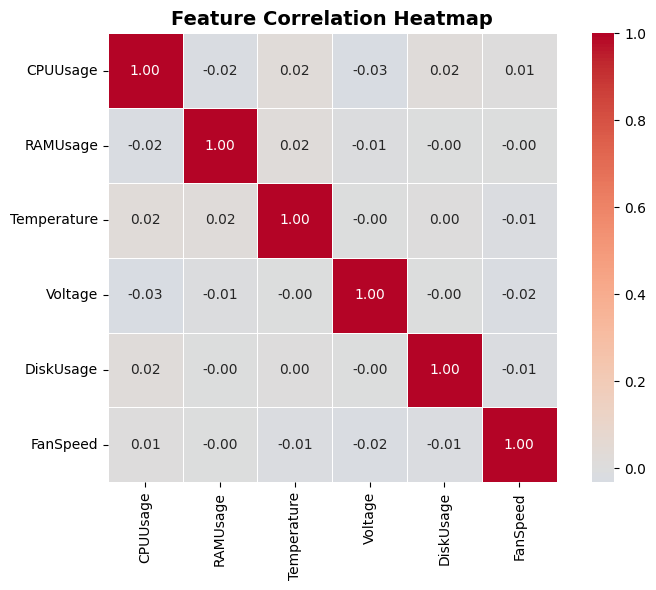

In [8]:
plt.figure(figsize=(8, 6))
numeric_df = df[['CPUUsage', 'RAMUsage', 'Temperature', 'Voltage', 'DiskUsage', 'FanSpeed']]
correlation = numeric_df.corr()

sns.heatmap(correlation,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Temperature Risk Analysis

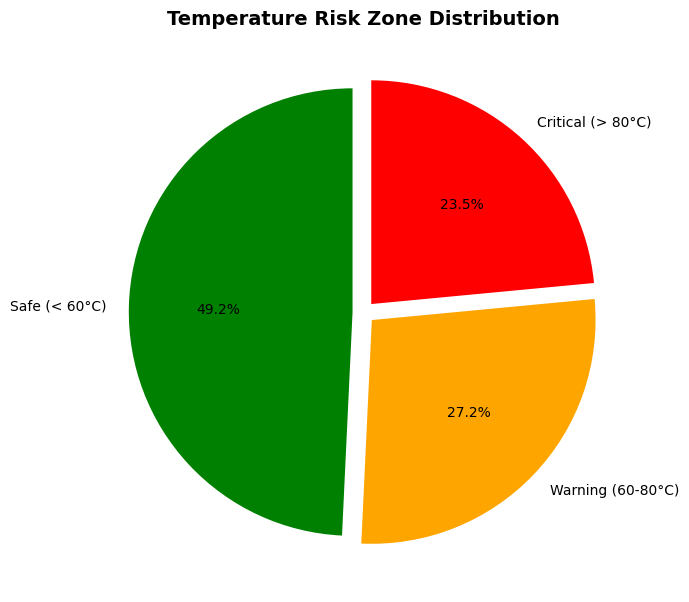


=== TEMPERATURE ZONE COUNTS ===
TempZone
Safe (< 60°C)        985
Warning (60-80°C)    545
Critical (> 80°C)    470
Name: count, dtype: int64


In [9]:
def classify_temp(temp):
    if temp < 60:
        return 'Safe (< 60°C)'
    elif temp < 80:
        return 'Warning (60-80°C)'
    else:
        return 'Critical (> 80°C)'

df['TempZone'] = df['Temperature'].apply(classify_temp)

zone_counts = df['TempZone'].value_counts()
colors_pie = ['green', 'orange', 'red']

plt.figure(figsize=(7, 7))
plt.pie(zone_counts,
        labels=zone_counts.index,
        autopct='%1.1f%%',
        colors=colors_pie,
        startangle=90,
        explode=(0.05, 0.05, 0.05))
plt.title('Temperature Risk Zone Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== TEMPERATURE ZONE COUNTS ===")
print(zone_counts)

### **Phase 2:Data Preprocessing**

Drop Unnecessary Columns & Encode Labels

In [10]:
# Step 1: Drop ModelName (not useful for training)
df_clean = df.drop(columns=['ModelName'])

print("=== AFTER DROPPING ModelName ===")
print(df_clean.head())
print(f"\nShape: {df_clean.shape}")

=== AFTER DROPPING ModelName ===
    CPUUsage   RAMUsage  Temperature    Voltage  DiskUsage  FanSpeed  \
0  48.447212  73.770260    59.971364  14.807143  15.502708      3507   
1  54.725241  25.221819    39.165106  15.727814   4.421022      1037   
2  26.693319  49.900628    93.052670  17.437338  25.180064      3244   
3  65.591652  29.603866    92.580189  10.645216  57.713538      3731   
4  24.395216  25.792754    76.175988  15.325681  83.788169      2830   

  ProblemDetected           TempZone  
0    Disk Failure      Safe (< 60°C)  
1      No Problem      Safe (< 60°C)  
2    Disk Failure  Critical (> 80°C)  
3      No Problem  Critical (> 80°C)  
4    Disk Failure  Warning (60-80°C)  

Shape: (2000, 8)


Encode ProblemDetected Column

In [11]:
# Step 2: Encode ProblemDetected (text → numbers)
# This converts categories to numbers the model can understand

problem_mapping = {
    'No Problem'  : 0,
    'Overheating' : 1,
    'Memory Leak' : 2,
    'Disk Failure': 3,
    'Power Issue' : 4
}

df_clean['ProblemEncoded'] = df_clean['ProblemDetected'].map(problem_mapping)
df_clean = df_clean.drop(columns=['ProblemDetected'])

print("=== ENCODED DATASET ===")
print(df_clean.head(10))
print(f"\nColumns: {df_clean.columns.tolist()}")

=== ENCODED DATASET ===
    CPUUsage   RAMUsage  Temperature    Voltage  DiskUsage  FanSpeed  \
0  48.447212  73.770260    59.971364  14.807143  15.502708      3507   
1  54.725241  25.221819    39.165106  15.727814   4.421022      1037   
2  26.693319  49.900628    93.052670  17.437338  25.180064      3244   
3  65.591652  29.603866    92.580189  10.645216  57.713538      3731   
4  24.395216  25.792754    76.175988  15.325681  83.788169      2830   
5  22.774119  90.248615    94.711862  12.996791  92.699733      3011   
6  93.613841  13.505777    45.575281  14.631244  47.984458      2570   
7  83.360361   9.684934    89.528878  13.720040  21.871661      2058   
8  18.526864  38.232166    64.916620  17.722543  60.529062      4829   
9  26.071981  36.366956    93.439256  12.326875  78.854244      3841   

            TempZone  ProblemEncoded  
0      Safe (< 60°C)               3  
1      Safe (< 60°C)               0  
2  Critical (> 80°C)               3  
3  Critical (> 80°C)       

Normalize All Features

In [12]:
# Step 3: Normalize features to range [0, 1]
# Neural networks train much better on normalized data

from sklearn.preprocessing import MinMaxScaler
import joblib

# Define which columns to normalize
feature_columns = ['CPUUsage', 'RAMUsage', 'Temperature',
                   'Voltage', 'DiskUsage', 'FanSpeed']

# Create and fit the scaler
scaler = MinMaxScaler()
df_clean[feature_columns] = scaler.fit_transform(df_clean[feature_columns])

print("=== NORMALIZED DATASET ===")
print(df_clean.head())

print("\n=== VALUE RANGES AFTER NORMALIZATION ===")
print(df_clean[feature_columns].describe().loc[['min', 'max']])

# Save scaler for later use (we'll need it to reverse normalization)
import os
save_path = '/content/drive/MyDrive/DRL-laptop-thermal-management/'
os.makedirs(save_path, exist_ok=True)
joblib.dump(scaler, save_path + 'scaler.pkl')
print("\n✅ Scaler saved to Google Drive!")

=== NORMALIZED DATASET ===
   CPUUsage  RAMUsage  Temperature   Voltage  DiskUsage  FanSpeed  \
0  0.484489  0.737991     0.499500  0.480517   0.153918  0.627534   
1  0.547277  0.252301     0.239198  0.572628   0.042793  0.009262   
2  0.266925  0.499194     0.913372  0.743663   0.250961  0.561702   
3  0.655954  0.296140     0.907461  0.064125   0.577201  0.683605   
4  0.243941  0.258013     0.702232  0.532396   0.838672  0.458073   

            TempZone  ProblemEncoded  
0      Safe (< 60°C)               3  
1      Safe (< 60°C)               0  
2  Critical (> 80°C)               3  
3  Critical (> 80°C)               0  
4  Warning (60-80°C)               3  

=== VALUE RANGES AFTER NORMALIZATION ===
     CPUUsage  RAMUsage  Temperature  Voltage  DiskUsage  FanSpeed
min       0.0       0.0          0.0      0.0        0.0       0.0
max       1.0       1.0          1.0      1.0        1.0       1.0

✅ Scaler saved to Google Drive!


Build World Model Training Data

In [13]:
# Goal: Given current state + action → predict next temperature
#
# We simulate "actions" as changes to FanSpeed
# Action 0 = decrease fan (-0.1)
# Action 1 = maintain fan (0)
# Action 2 = increase fan (+0.1)
# ============================================

import numpy as np

# Create action column (simulate random actions taken)
np.random.seed(42)
actions = np.random.choice([-0.1, 0.0, 0.1], size=len(df_clean))
df_clean['Action'] = actions

# Create next_temperature (target variable)
# Physics logic: higher fan action → temperature drops slightly
# This injects realistic behavior into synthetic data
df_clean['Next_Temperature'] = (
    df_clean['Temperature']
    - (actions * 0.15)                          # fan action effect
    + (df_clean['CPUUsage'] * 0.05)             # CPU load heats things up
    - (df_clean['RAMUsage'] * 0.01)             # small RAM effect
    + np.random.normal(0, 0.02, len(df_clean))  # small random noise
).clip(0, 1)  # keep within normalized range

print("=== WORLD MODEL TRAINING DATA ===")
print(df_clean[['CPUUsage', 'RAMUsage', 'Temperature',
                'FanSpeed', 'Action', 'Next_Temperature']].head(10))

print(f"\nFinal dataset shape: {df_clean.shape}")
print(f"Columns: {df_clean.columns.tolist()}")

=== WORLD MODEL TRAINING DATA ===
   CPUUsage  RAMUsage  Temperature  FanSpeed  Action  Next_Temperature
0  0.484489  0.737991     0.499500  0.627534     0.1          0.534775
1  0.547277  0.252301     0.239198  0.009262    -0.1          0.274958
2  0.266925  0.499194     0.913372  0.561702     0.1          0.903005
3  0.655954  0.296140     0.907461  0.683605     0.1          0.943153
4  0.243941  0.258013     0.702232  0.458073    -0.1          0.736969
5  0.227728  0.902845     0.934130  0.503379    -0.1          0.911540
6  0.936209  0.135091     0.319394  0.392991     0.1          0.332986
7  0.833662  0.096866     0.869287  0.264831     0.0          0.909730
8  0.185250  0.382460     0.561369  0.958448     0.1          0.524413
9  0.260710  0.363800     0.918209  0.711139     0.1          0.903123

Final dataset shape: (2000, 10)
Columns: ['CPUUsage', 'RAMUsage', 'Temperature', 'Voltage', 'DiskUsage', 'FanSpeed', 'TempZone', 'ProblemEncoded', 'Action', 'Next_Temperature']


Split into Train/Test & Save

In [14]:
# 80% training, 20% testing

from sklearn.model_selection import train_test_split

# Features (inputs to world model)
X = df_clean[['CPUUsage', 'RAMUsage', 'Temperature',
              'Voltage', 'DiskUsage', 'FanSpeed', 'Action']].values

# Target (what we want to predict)
y = df_clean['Next_Temperature'].values

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("=== DATA SPLIT ===")
print(f"Training samples  : {X_train.shape[0]}")
print(f"Testing samples   : {X_test.shape[0]}")
print(f"Input features    : {X_train.shape[1]}")

# Save processed data
np.save(save_path + 'X_train.npy', X_train)
np.save(save_path + 'X_test.npy',  X_test)
np.save(save_path + 'y_train.npy', y_train)
np.save(save_path + 'y_test.npy',  y_test)

print("\n✅ Preprocessed data saved to Google Drive!")
print("✅ Phase 2 Complete! Ready to build the World Model.")

=== DATA SPLIT ===
Training samples  : 1600
Testing samples   : 400
Input features    : 7

✅ Preprocessed data saved to Google Drive!
✅ Phase 2 Complete! Ready to build the World Model.


### **Phase 3: Build the ANN World Model**

In [15]:
# ============================================
# PHASE 3 - ANN WORLD MODEL
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

# Check if GPU is available (Colab gives free GPU!)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

✅ Using device: cpu
PyTorch version: 2.11.0+cpu


Load Saved Data & Prepare Tensors

In [16]:
save_path = '/content/drive/MyDrive/DRL-laptop-thermal-management/'

X_train = np.load(save_path + 'X_train.npy')
X_test  = np.load(save_path + 'X_test.npy')
y_train = np.load(save_path + 'y_train.npy')
y_test  = np.load(save_path + 'y_test.npy')

# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1).to(device)
y_test_t  = torch.FloatTensor(y_test).unsqueeze(1).to(device)

# Create DataLoaders (feeds data in batches during training)
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print("✅ Data loaded and converted to tensors!")
print(f"X_train shape : {X_train_t.shape}")
print(f"y_train shape : {y_train_t.shape}")
print(f"X_test shape  : {X_test_t.shape}")
print(f"y_test shape  : {y_test_t.shape}")

✅ Data loaded and converted to tensors!
X_train shape : torch.Size([1600, 7])
y_train shape : torch.Size([1600, 1])
X_test shape  : torch.Size([400, 7])
y_test shape  : torch.Size([400, 1])


Define the ANN Architecture

In [17]:
# ============================================
# ANN WORLD MODEL ARCHITECTURE
#
#  Input Layer  : 7 features
#                 (CPUUsage, RAMUsage, Temperature,
#                  Voltage, DiskUsage, FanSpeed, Action)
#  Hidden Layer 1: 128 neurons
#  Hidden Layer 2: 64 neurons
#  Hidden Layer 3: 32 neurons
#  Output Layer  : 1 value (Next_Temperature)
# ============================================

class WorldModel(nn.Module):
    def __init__(self):
        super(WorldModel, self).__init__()

        self.network = nn.Sequential(
            # Input → Hidden Layer 1
            nn.Linear(7, 128),
            nn.ReLU(),
            nn.Dropout(0.2),         # prevents overfitting

            # Hidden Layer 1 → Hidden Layer 2
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            # Hidden Layer 2 → Hidden Layer 3
            nn.Linear(64, 32),
            nn.ReLU(),

            # Hidden Layer 3 → Output
            nn.Linear(32, 1),
            nn.Sigmoid()             # output between 0-1 (normalized temp)
        )

    def forward(self, x):
        return self.network(x)

# Create the model
model = WorldModel().to(device)

# Print model summary
print("=== WORLD MODEL ARCHITECTURE ===")
print(model)

# Count total parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {total_params:,}")

=== WORLD MODEL ARCHITECTURE ===
WorldModel(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
    (9): Sigmoid()
  )
)

Total trainable parameters: 11,393


Train the World Model

In [18]:
# Loss function and optimizer
criterion = nn.MSELoss()                           # Mean Squared Error
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

# Training settings
EPOCHS = 100
train_losses = []
test_losses  = []

print("=== TRAINING STARTED ===\n")

for epoch in range(EPOCHS):

    # --- TRAINING PHASE ---
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()          # clear old gradients
        predictions = model(X_batch)   # forward pass
        loss = criterion(predictions, y_batch)  # calculate loss
        loss.backward()                # backpropagation
        optimizer.step()               # update weights
        train_loss += loss.item()

    # --- TESTING PHASE ---
    model.eval()
    test_loss = 0.0

    with torch.no_grad():              # no gradient calculation needed
        for X_batch, y_batch in test_loader:
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            test_loss += loss.item()

    # Average losses
    avg_train_loss = train_loss / len(train_loader)
    avg_test_loss  = test_loss  / len(test_loader)

    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)

    scheduler.step()

    # Print every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1:3d}/{EPOCHS}] | "
              f"Train Loss: {avg_train_loss:.6f} | "
              f"Test Loss: {avg_test_loss:.6f}")

print("\n✅ Training Complete!")

=== TRAINING STARTED ===

Epoch [ 10/100] | Train Loss: 0.003877 | Test Loss: 0.001521
Epoch [ 20/100] | Train Loss: 0.002378 | Test Loss: 0.001022
Epoch [ 30/100] | Train Loss: 0.002099 | Test Loss: 0.000766
Epoch [ 40/100] | Train Loss: 0.001742 | Test Loss: 0.000772
Epoch [ 50/100] | Train Loss: 0.001607 | Test Loss: 0.000707
Epoch [ 60/100] | Train Loss: 0.001577 | Test Loss: 0.000630
Epoch [ 70/100] | Train Loss: 0.001490 | Test Loss: 0.000621
Epoch [ 80/100] | Train Loss: 0.001447 | Test Loss: 0.000723
Epoch [ 90/100] | Train Loss: 0.001423 | Test Loss: 0.000608
Epoch [100/100] | Train Loss: 0.001478 | Test Loss: 0.000614

✅ Training Complete!


Plot Training Results

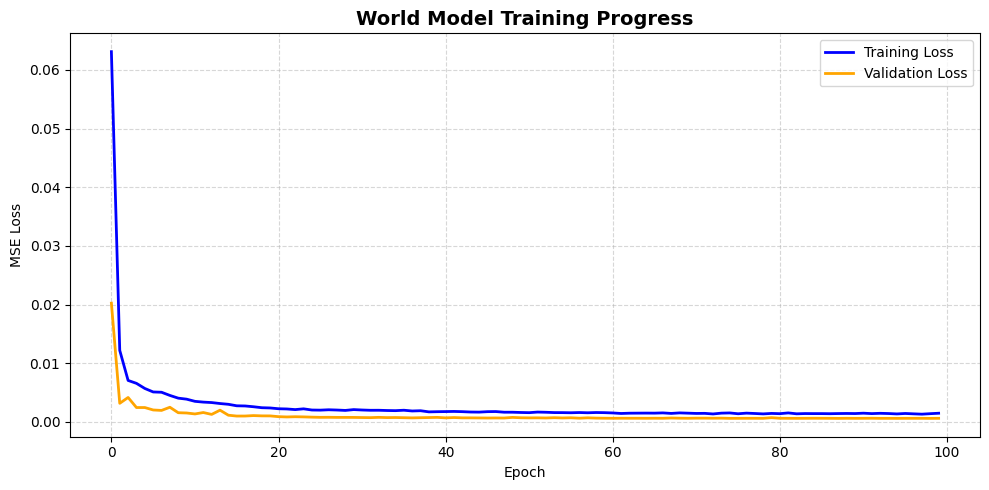

Final Training Loss : 0.001478
Final Test Loss     : 0.000614


In [19]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss',   color='blue',  linewidth=2)
plt.plot(test_losses,  label='Validation Loss', color='orange', linewidth=2)
plt.title('World Model Training Progress', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Final Training Loss : {train_losses[-1]:.6f}")
print(f"Final Test Loss     : {test_losses[-1]:.6f}")

Evaluate & Save the Model

=== WORLD MODEL PERFORMANCE ===
MSE  (lower is better) : 0.000611
MAE  (lower is better) : 0.020245
R²   (higher is better): 0.992542


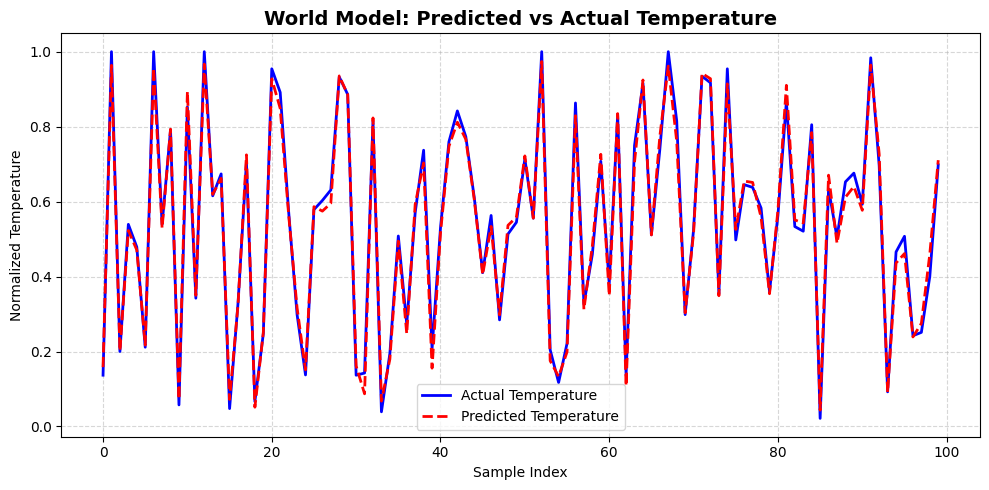


✅ World Model saved to Google Drive!
✅ Phase 3 Complete! Ready to build the RL Environment.


In [20]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test_t).cpu().numpy().flatten()
    y_true = y_test_t.cpu().numpy().flatten()

# Calculate metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse  = mean_squared_error(y_true, y_pred)
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)

print("=== WORLD MODEL PERFORMANCE ===")
print(f"MSE  (lower is better) : {mse:.6f}")
print(f"MAE  (lower is better) : {mae:.6f}")
print(f"R²   (higher is better): {r2:.6f}")

# Plot predictions vs actual
plt.figure(figsize=(10, 5))
plt.plot(y_true[:100],  label='Actual Temperature',    color='blue',  linewidth=2)
plt.plot(y_pred[:100],  label='Predicted Temperature', color='red',   linewidth=2, linestyle='--')
plt.title('World Model: Predicted vs Actual Temperature', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('Normalized Temperature')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Save the trained model
torch.save(model.state_dict(), save_path + 'world_model.pth')
print("\n✅ World Model saved to Google Drive!")
print("✅ Phase 3 Complete! Ready to build the RL Environment.")